In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [6]:
import os # 모델 저장할 폴더가 있는지 여부와 폴더 생성
import numpy as np
import pandas as pd # get_dummies(원핫인코딩), crosstab
import seaborn as sns # iris데이터(데이터프레임) 가져오기
from sklearn import datasets # iris데이터(X,y) 가져오기
from sklearn.preprocessing import LabelEncoder # 라벨인코더
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from sklearn.preprocessing import StandardScaler # , MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, LeakyReLU
from tensorflow.keras import metrics
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns
sns.load_dataset('iris')

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# iris

```
X, y(라벨인코딩-원핫인코딩)분리 -> train과  test셋 분리(8:2)
모델 구성(입력4->출력3, layer5 : 4->64->128->50->30->3)
모델 학습과정 설정
모델 학습(Earlystopping, ModelCheckpoint추가)
모델 평가(시각화, 현재 모델과 저장된 최고의 모델 평가, 교차표== 혼동행렬)
모델예측/저장)
```

## 1. 데이터 셋 생성(seaborn) & 전처리

In [10]:
iris_data = sns.load_dataset('iris')
X_iris = iris_data.iloc[:,:-1]
y_iris = iris_data.iloc[:,-1]
X_iris.shape, y_iris.shape

((150, 4), (150,))

In [16]:
# y_iris 원핫인코딩
Y_iris = pd.get_dummies(y_iris).to_numpy()
# Y_iris

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X_iris, Y_iris,
                                                   train_size=0.8,
                                                   stratify=Y_iris)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((120, 4), (120, 3), (30, 4), (30, 3))

## 2 모델 구성

In [19]:
model = Sequential()
model.add(Input(4))
model.add(Dense(64, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(50, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(3, activation='sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                320       
                                                                 
 dense_1 (Dense)             (None, 128)               8320      
                                                                 
 dense_2 (Dense)             (None, 50)                6450      
                                                                 
 dense_3 (Dense)             (None, 30)                1530      
                                                                 
 dense_4 (Dense)             (None, 3)                 93        
                                                                 
Total params: 16,713
Trainable params: 16,713
Non-trainable params: 0
_________________________________________________________________


## 3 모델 학습과정 설정

In [21]:
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

## 4. 학습시키기

In [23]:
model_save_folder='./model'
file = model_save_folder + "iris-{epoch:03d}-loss{val_loss:.4f}-acc{val_accuracy:.4f}.h5"
            
checkpoint = ModelCheckpoint(
                filepath=file,
                monitor= 'var_accuracy',
                save_best_only=True,
                mode='max',
                verbose=0)
earlyStopping = EarlyStopping(monitor='val_loss', patience=30)
hist = model.fit(X_train, Y_train, epochs=50, batch_size=100,
                validation_split=0.2,
                verbose=1,
                callbacks=[earlyStopping,checkpoint])

Epoch 1/50
1/1 [==============================] - 1s 562ms/step - loss: 1.1212 - accuracy: 0.3333 - val_loss: 1.1051 - val_accuracy: 0.3333
Epoch 2/50
1/1 [==============================] - 0s 26ms/step - loss: 1.0782 - accuracy: 0.3333 - val_loss: 1.0731 - val_accuracy: 0.3750
Epoch 3/50
1/1 [==============================] - 0s 34ms/step - loss: 1.0503 - accuracy: 0.3854 - val_loss: 1.0458 - val_accuracy: 0.5000
Epoch 4/50
1/1 [==============================] - 0s 16ms/step - loss: 1.0268 - accuracy: 0.6042 - val_loss: 1.0217 - val_accuracy: 0.5417
Epoch 5/50
1/1 [==============================] - 0s 25ms/step - loss: 1.0064 - accuracy: 0.6458 - val_loss: 1.0026 - val_accuracy: 0.4583
Epoch 6/50
1/1 [==============================] - 0s 26ms/step - loss: 0.9906 - accuracy: 0.5208 - val_loss: 0.9799 - val_accuracy: 0.3333
Epoch 7/50
1/1 [==============================] - 0s 31ms/step - loss: 0.9713 - accuracy: 0.3333 - val_loss: 0.9566 - val_accuracy: 0.3333
Epoch 8/50
1/1 [==========

1/1 [==============================] - 0s 36ms/step - loss: 0.6637 - accuracy: 0.8229 - val_loss: 0.6415 - val_accuracy: 0.8333
Epoch 29/50
1/1 [==============================] - 0s 31ms/step - loss: 0.6449 - accuracy: 0.8438 - val_loss: 0.6209 - val_accuracy: 0.8333
Epoch 30/50
1/1 [==============================] - 0s 33ms/step - loss: 0.6259 - accuracy: 0.8542 - val_loss: 0.5998 - val_accuracy: 0.8333
Epoch 31/50
1/1 [==============================] - 0s 28ms/step - loss: 0.6070 - accuracy: 0.8646 - val_loss: 0.5786 - val_accuracy: 0.8333
Epoch 32/50
1/1 [==============================] - 0s 17ms/step - loss: 0.5879 - accuracy: 0.8750 - val_loss: 0.5577 - val_accuracy: 0.8333
Epoch 33/50
1/1 [==============================] - 0s 34ms/step - loss: 0.5690 - accuracy: 0.8750 - val_loss: 0.5385 - val_accuracy: 0.8333
Epoch 34/50
1/1 [==============================] - 0s 31ms/step - loss: 0.5509 - accuracy: 0.8958 - val_loss: 0.5201 - val_accuracy: 0.8333
Epoch 35/50
1/1 [===============

## 5. 모델 평가하기

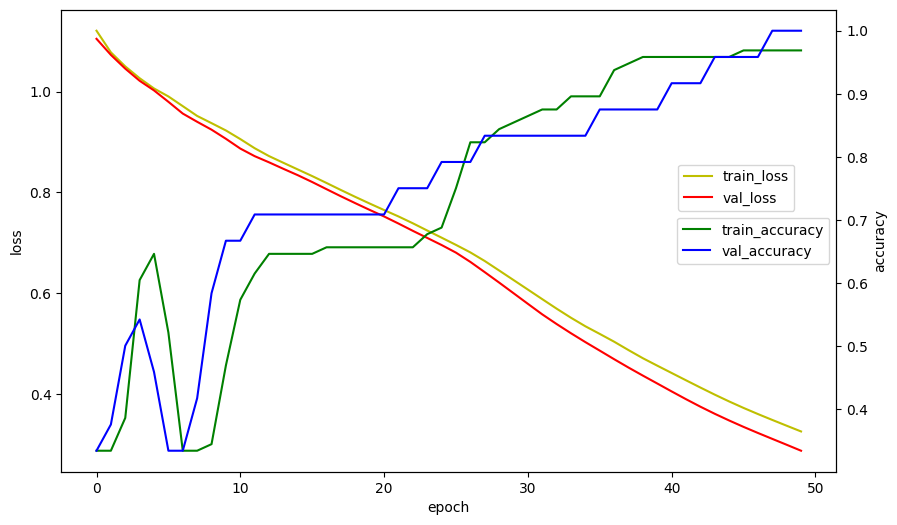

In [24]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [25]:
# 모델 평가
loss_and_acc = model.evaluate(X_test, Y_test, batch_size=100, verbose=0)
print(f'loss :{loss_and_acc[0]}, accuracy:{loss_and_acc[1]:.4f}')

loss :0.360735684633255, accuracy:0.9667


In [61]:
real = Y_test.argmax(axis=1)
pred = model.predict(X_test).argmax(axis=1)

pd.crosstab(real,pred, rownames=['real'], colnames=['pred'])

1/1 [==============================] - 0s 15ms/step


pred,0,1,2
real,,,
0,10,0,0
1,0,9,1
2,0,0,10


In [67]:
X_iris[:1]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


In [69]:
input_data=[5.1,3.5,1.4,0.2]
model.predict([input_data]).argmax(axis=1)

1/1 [==============================] - 0s 49ms/step


array([0], dtype=int64)